<a href="https://colab.research.google.com/github/mabrisenom-spec/intento/blob/main/Notebook_Basico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 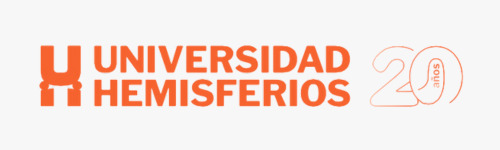
> Presentado Por: Briseño Martínez Manuel Amable

> Módulo: MTDI202 Big Data, Analytics & Data Scientist

> Docente: Ing. Carlos Wladimir Carrillo Villavicencio MSc. TIC.

> Tema de Análisis: Segmentación de clientes para identificar características de consumo.

> Fecha: 10-07-2026


# Índice de Contenido

*   Portada del Notebook
*   Índice de Contenido
*   Carga de Librerias
*   Lectura del Dataset
*   Descripción del Dataset
*   Limpieza y preparación de Datos
*   Análisis Exploratorio de Datos
*   Visualización de Datos
*   Machine Básico de Datos
*   Resultados y Conclusiones


# Carga de Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


## Lectura del Dataset

In [5]:
import pandas as pd
ruta = '/content/Segmentacion de Mercado.csv.xlsx'
df = pd.read_excel(ruta)
df.head()

,Identidad,Año de Nacimiento,Educación,Estado Civil,Ingresos,Hogar Niños,Hogar Adolecentes,Fecha de consumo,Días después de la última compra,Gasto en Vinos,...,Compras Sitio Web,Aceptado 1,Aceptado 2,Aceptado 3,Aceptado 4,Aceptado 5,Quejas,Costos,Ingresos Z,Respuesta
0,5524,1905-05-10,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1905-05-07,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1905-05-18,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1905-06-06,Graduation,Together,26646.0,1,1,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1905-06-03,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Identidad                         2240 non-null   int64         
 1   Año de Nacimiento                 2240 non-null   datetime64[ns]
 2   Educación                         2240 non-null   object        
 3   Estado Civil                      2240 non-null   object        
 4   Ingresos                          2216 non-null   float64       
 5   Hogar Niños                       2240 non-null   int64         
 6   Hogar Adolecentes                 2240 non-null   int64         
 7   Fecha de consumo                  2240 non-null   datetime64[ns]
 8   Días después de la última compra  2240 non-null   int64         
 9   Gasto en Vinos                    2240 non-null   int64         
 10  Gasto Frutas                      2240 non-null 

Se verifica la información de la base de datos a interpretar e identificando los tipos de datos sean Númenricos y Categoricos

In [190]:
df.dtypes

,0
Identidad,int64
Año de Nacimiento,datetime64[ns]
Educación,object
Estado Civil,object
Ingresos,float64
Hogar Niños,int64
Hogar Adolecentes,int64
Fecha de consumo,datetime64[ns]
Días después de la última compra,int64
Gasto en Vinos,int64


Se identifica los tipos de columnas existentes en el Dateset

# Descripción del Dataset
Archivo de Excel con datos de segmentación de mercado enfocados a caracteristicas de consumo.

> Fuente: https://www.kaggle.com

> Tamaño: 220,19 KB con 29 columnas

> Tipo de Variables: x= Estado Civil y= Gastos en Vinos

> Tipo de Datos: Númericos, Categoricos y Datos de Tiempo

> Variable Objetivo: Gastos en Vinos













# LImpieza y Exploración
Antes de aplicar cualquier modelo, es fundamental comprender la estructura de los datos, identificar valores nulos y realizar transformaciones necesarias.

In [8]:
df["Fecha de consumo"]=pd.to_datetime(df["Fecha de consumo"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Identidad                         2240 non-null   int64         
 1   Año de Nacimiento                 2240 non-null   datetime64[ns]
 2   Educación                         2240 non-null   object        
 3   Estado Civil                      2240 non-null   object        
 4   Ingresos                          2216 non-null   float64       
 5   Hogar Niños                       2240 non-null   int64         
 6   Hogar Adolecentes                 2240 non-null   int64         
 7   Fecha de consumo                  2240 non-null   datetime64[ns]
 8   Días después de la última compra  2240 non-null   int64         
 9   Gasto en Vinos                    2240 non-null   int64         
 10  Gasto Frutas                      2240 non-null 

Se obtienen los datos de tipo fecha para realizar los diferentes análisis según lo requerido.

In [58]:
df.describe(include="object")

,Educación,Estado Civil
count,2240,2240
unique,5,8
top,Graduation,Married
freq,1127,864


Según los datos obtenidos de la tabla de las variables a estudiar el top en educación son los grduados y en estado civil los married.

In [21]:
import plotly.express as px
figure1=px.line(df, x="Estado Civil", y="Gasto en Vinos", title="Gastos en Licores Según el Estdo Civil")
figure1.show()

Interpretación:
Se determina que los que gastan más dinero en la commpra de Vinos son los Together con 1492 dólares y Married con 1493 dólares de consumo anual.

Se define las Variables de estudio


> x= Estado Civil


> y= Gastos en Vinos





In [28]:
print(df.shape)
df.info()
df.describe(include='all').T

(2240, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Identidad                         2240 non-null   int64         
 1   Año de Nacimiento                 2240 non-null   datetime64[ns]
 2   Educación                         2240 non-null   object        
 3   Estado Civil                      2240 non-null   object        
 4   Ingresos                          2216 non-null   float64       
 5   Hogar Niños                       2240 non-null   int64         
 6   Hogar Adolecentes                 2240 non-null   int64         
 7   Fecha de consumo                  2240 non-null   datetime64[ns]
 8   Días después de la última compra  2240 non-null   int64         
 9   Gasto en Vinos                    2240 non-null   int64         
 10  Gasto Frutas                      224

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Identidad,2240.0,NaN,NaN,NaN,5592.159821,0.0,2828.25,5458.5,8427.75,11191.0,3246.662198
Año de Nacimiento,2240,NaN,NaN,NaN,1905-05-21 19:20:21.428571392,1905-03-07 00:00:00,1905-05-12 00:00:00,1905-05-23 00:00:00,1905-05-30 00:00:00,1905-06-18 00:00:00,NaN
Educación,2240,5,Graduation,1127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estado Civil,2240,8,Married,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ingresos,2216.0,NaN,NaN,NaN,52247.251354,1730.0,35303.0,51381.5,68522.0,666666.0,25173.076661
Hogar Niños,2240.0,NaN,NaN,NaN,0.444196,0.0,0.0,0.0,1.0,2.0,0.538398
Hogar Adolecentes,2240.0,NaN,NaN,NaN,0.506696,0.0,0.0,0.0,1.0,2.0,0.544533
Fecha de consumo,2240,NaN,NaN,NaN,2013-07-10 10:01:42.857142784,2012-07-30 00:00:00,2013-01-16 00:00:00,2013-07-08 12:00:00,2013-12-30 06:00:00,2014-06-29 00:00:00,NaN
Días después de la última compra,2240.0,NaN,NaN,NaN,49.109375,0.0,24.0,49.0,74.0,99.0,28.962453
Gasto en Vinos,2240.0,NaN,NaN,NaN,303.935714,0.0,23.75,173.5,504.25,1493.0,336.597393


En la siguiente tabla se observa todos los datos requeridos para el estudio a realizar acerca de los consumidores de determinado producto.

In [29]:
df.isnull().sum().sort_values(ascending=False)

,0
Ingresos,24
Identidad,0
Año de Nacimiento,0
Educación,0
Estado Civil,0
Hogar Niños,0
Hogar Adolecentes,0
Fecha de consumo,0
Días después de la última compra,0
Gasto en Vinos,0


Muestra los valores cortos en una tabla específica para mejor visualización.

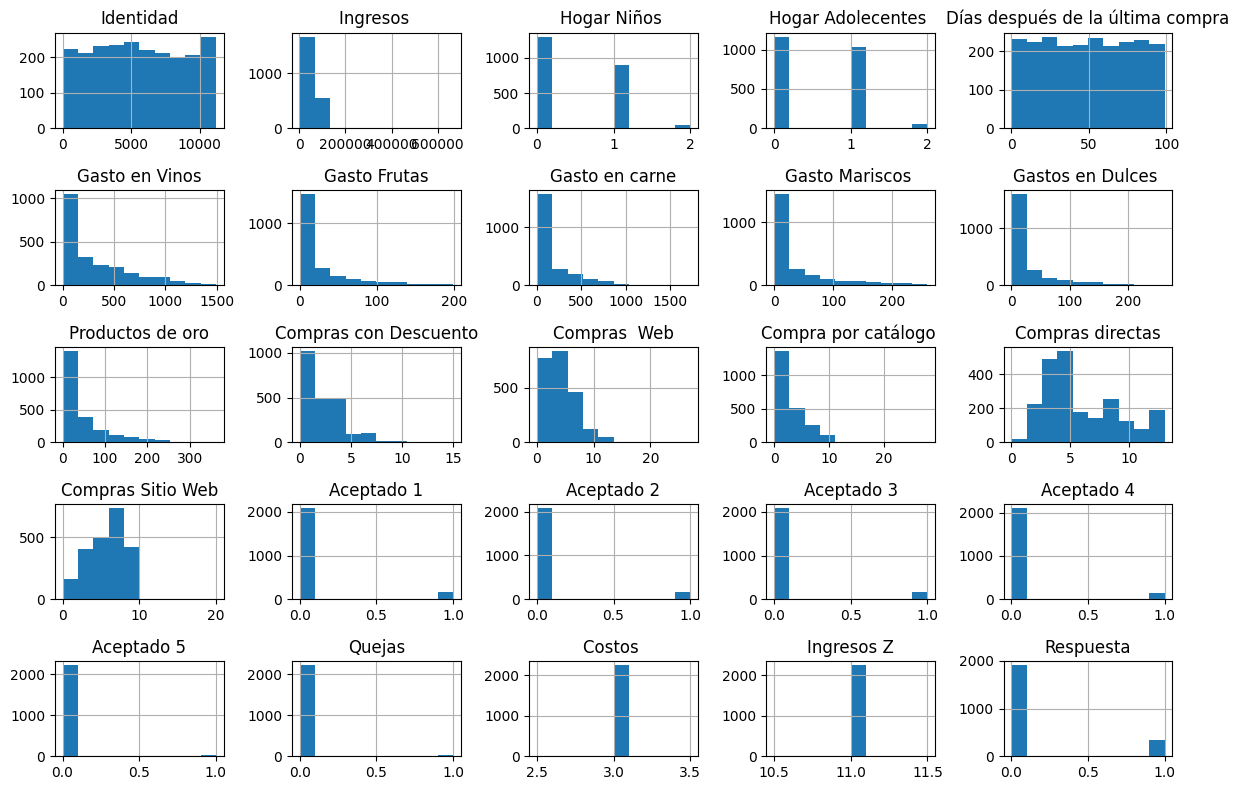

In [30]:
import numpy as np
import matplotlib.pyplot as plt
num_cols = df.select_dtypes(include=np.number).columns
if len(num_cols) > 0:
    df[num_cols].hist(figsize=(12,8))
    plt.tight_layout()
    plt.show()

# Análisis y exploración de datos

Estadísticas descriptivas:
Rango = Difernecia entre el Máximo y Mínimo

In [55]:
df["Gasto en Vinos"].max()-df["Gasto en Vinos"].min()

1493

Se determino que el Rango de Gastos en Vino es de 1493

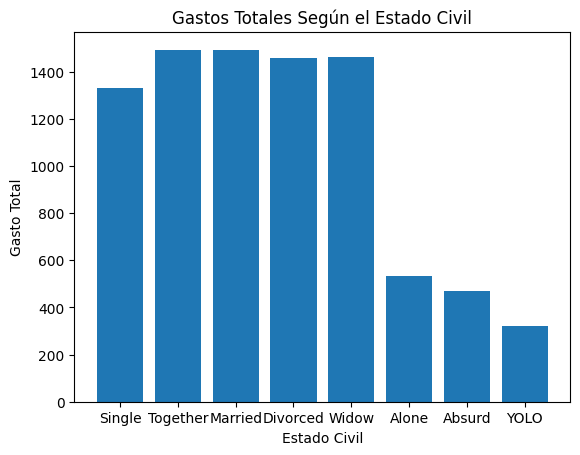

In [44]:
import matplotlib.pyplot as plt
y=df["Gasto en Vinos"]
x=df["Estado Civil"]
plt.bar(x,y)
plt.xlabel("Estado Civil")
plt.ylabel("Gasto Total")
plt.title("Gastos Totales Según el Estado Civil")
plt.show()

Según la figura obtenida, se puede determinar que el gasto en vinos es realizado en la mayoria por los Together y Married con un promedio de 1493 dólares anuales en compras de este producto.

In [65]:
avg_ingresos_por_estado_civil = df.groupby('Estado Civil')['Ingresos '].mean().reset_index()
display(avg_ingresos_por_estado_civil)

,Estado Civil,Ingresos
0,Absurd,72365.500000
1,Alone,43789.000000
2,Divorced,52834.228448
3,Married,51724.978996
4,Single,50995.350318
5,Together,53245.534031
6,Widow,56481.552632
7,YOLO,48432.000000


Se determinó los ingresos obtenidos según el estado civil de cada persona estudiada.

## Gráficos

## Distribución de los ingresos

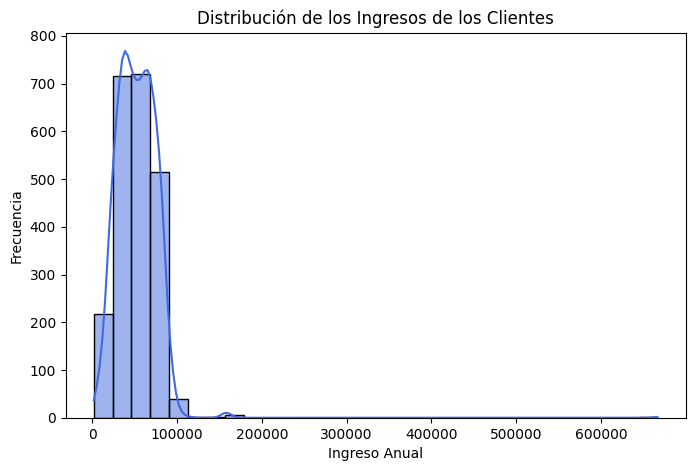

In [119]:
plt.figure(figsize=(8,5))
sns.histplot(df["Ingresos "], bins=30, kde=True, color="royalblue")
plt.title("Distribución de los Ingresos de los Clientes")
plt.xlabel("Ingreso Anual")
plt.ylabel("Frecuencia")
plt.show()

In [76]:
figure2=px.bar(avg_ingresos_por_estado_civil, x="Estado Civil", y="Ingresos ", title="Ingresos Promedio Según el Estado Civil")
figure2.show()

Se visualiza los ingresos anuales según el estado civil de cada persona siendo los viudos los que generan más ingrsos con 56.481 anuales.

In [80]:
figure3=px.box(df, x="Estado Civil", y="Gasto en Vinos", title="Gastos en Vino Según el Estado Civil")
figure3.show()

Se puede observar que los gastos en vino anualmente lo realizan en su mayoria las personas casadas con un gasto máximo de 1493 dólares.

In [92]:
figure4=px.bar(df, x="Educación ", y="Ingresos ", title= "Ingresos Según Educación")
figure4.show()

In [8]:
figure5=px.bar(df, x="Educación ", y="Fecha de consumo", title= "Años de ser cliente")
figure5.show()

Según los datos obtenidos las personas graduadas son las que más ingresos generan ingresos con hasta 34.421 de promedio anual.

# Machine Learning básico

In [9]:
df.isnull().sum()

,0
Identidad,0
Año de Nacimiento,0
Educación,0
Estado Civil,0
Ingresos,24
Hogar Niños,0
Hogar Adolecentes,0
Fecha de consumo,0
Días después de la última compra,0
Gasto en Vinos,0


In [11]:
from sklearn.model_selection import train_test_split

target= "Estado Civil"
X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Se realiza la separación de los datos para entrenamiento y prueba del modelo

Ingreso de las librerias requeridas

In [12]:
target= "Estado Civil"
X = df.drop(target, axis=1)
y = df[target]

Variable Objetivo: Estado Civil



In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_features = X.select_dtypes(include=np.number).columns
cat_features = X.select_dtypes(exclude=np.number).columns

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.453125
              precision    recall  f1-score   support

      Absurd       0.00      0.00      0.00         1
    Divorced       1.00      0.07      0.14        55
     Married       0.41      0.88      0.56       159
      Single       0.51      0.22      0.31        99
    Together       0.64      0.30      0.40       115
       Widow       1.00      0.16      0.27        19

    accuracy                           0.45       448
   macro avg       0.59      0.27      0.28       448
weighted avg       0.59      0.45      0.40       448



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [18]:
train_test_split(X, y, test_size=0.2, random_state=42)

[      Identidad Año de Nacimiento  Educación   Ingresos   Hogar Niños   \
 792        3479        1905-05-03  Graduation    16813.0             0   
 1271       7488        1905-05-16      Master    64191.0             0   
 1538       1079        1905-05-24         PhD    71969.0             0   
 668       11007        1905-05-21         PhD    29187.0             1   
 1975      10311        1905-05-22  Graduation     4428.0             0   
 ...         ...               ...         ...        ...           ...   
 1638      10785        1905-05-22  Graduation    44078.0             1   
 1095       9964        1905-06-01  Graduation    61825.0             0   
 1130       3412        1905-05-04      Master    67381.0             0   
 1294       2811        1905-05-16         PhD    48918.0             1   
 860        4297        1905-05-22  Graduation    23228.0             1   
 
       Hogar Adolecentes  Fecha de consumo  Días después de la última compra  \
 792              

## Precisión

In [19]:
from sklearn.metrics import precision_score
precision_score(y_test, pred, average='weighted')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



0.586934122381234

La precisión del modelo implementado es de un 0.58 es decir que solamente el 58 % son prediciones verdaderas.

## Recall

In [21]:
from sklearn.metrics import recall_score, f1_score
f1_score(y_test, pred, average='weighted')

0.39775994200768483

El modelo detecto un 19 % de casos positivos existentes

El modelo Randaom Forest el cual alcanzó una exactitud de 57 %, con un F1 Score de 0.59. las variables más representativas fueron estado civil, educación, gastos en vinos y compras con descuento.

In [26]:
pd.crosstab(["Estado Civil"],["Educación"])

col_0,Educación
row_0,
Estado Civil,1


In [28]:
pd.crosstab(df["Estado Civil"], df["Educación "], margins=True)

Educación,2n Cycle,Basic,Graduation,Master,PhD,All
Estado Civil,,,,,,
Absurd,0,0,1,1,0,2
Alone,0,0,1,1,1,3
Divorced,23,1,119,37,52,232
Married,81,20,433,138,192,864
Single,37,18,252,75,98,480
Together,57,14,286,106,117,580
Widow,5,1,35,12,24,77
YOLO,0,0,0,0,2,2
All,203,54,1127,370,486,2240


# Resultados y conclusiones

## Resultados
Al desarrollar este Notebook permitió realizar un Análisis Exploratorio de datos y explicar un modelo básico de Maching Learnig, implementando las diferentes etapas a seguir elementales para un proyecto.
Se definio las variables de estudio X = Estado Civil y la Variable y= Gastos en Vino. Determinado el Estado Civil como la variable Objetivo del presente estudio.
Con los datos obtenidos sobre cómo influye el estado civil en la compra de un vino se puede predecir que un 57 % de las personas con ese estado pueden adquirir el producto



## Conclusiones
El Notebook demuestra que la combinación del EDA y Maching Learning permite obtener información relevante para una mejor toma de decisiones en todo tipo de negocios.
Se puede construir modelos expresamente enfocados en los procesos de análisis de datos para una mejor segmentación de Mercado.
Además, con una validación de datos sólida se obtendría meojores resultados al momento de implementar estrategias de ventas de productos enfocados a segmentos de mercado exclusivos.